# Projet *Walmart Sales* – Certification CDSD – bloc 3

<br><br>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5b/Walmart_logo_%282025%29.svg/960px-Walmart_logo_%282025%29.svg.png" alt="Walmart logo" width="400">
<br><br>

Auteur : Yoann ROBERT

Date de la présentation : 16 juin 2026

---

## Introduction

### Contexte

Walmart est une multinationale américaine de la grande distribution. Le service marketing de l'entreprise souhaite disposer d'un modèle de *machine learning* capable d'estimer le chiffre d'affaires hebdomadaire de ses magasins avec la meilleure précision possible. Un tel outil permettrait de mieux comprendre l'influence des indicateurs économiques sur les ventes et de planifier les futures campagnes marketing.

### Dataset

Le jeu de données provient d'une compétition Kaggle, retravaillé par Jedha pour les besoins pédagogiques. Il comporte 150 lignes et 8 colonnes dont une colonne qui décrit les ventes hebdomadaires de différents magasins, les autres étant des variables contextuelles :
- `Store` : identifiant du magasin
- `Date` : date de relevé hebdomadaire
- `Weekly_Sales` : chiffre d'affaires hebdomadaire (variable cible)
- `Holiday_Flag` : présence d'un jour férié dans la semaine
- `Temperature` : température (°F)
- `Fuel_Price` : prix du carburant (USD/gallon)
- `CPI` : indice des prix à la consommation
- `Unemployment` : taux de chômage

### Objectifs

Construire un modèle de régression supervisé prédisant `Weekly_Sales` à partir des autres variables, en suivant une démarche en trois temps : analyse exploratoire et préparation des données, entraînement d'une régression linéaire de référence, puis lutte contre le surapprentissage à l'aide d'une régression régularisée.

### Indications

Plusieurs contraintes méthodologiques encadrent le projet :
- aucune imputation n'est appliquée sur la variable cible : les lignes où `Weekly_Sales` est manquante sont supprimées
- la colonne `Date` doit être décomposée en variables numériques exploitables (année, mois, jour, jour de la semaine)
- sont considérées comme aberrantes toutes les valeurs des variables numériques `Temperature`, `Fuel_Price`, `CPI` et `Unemployment` situées hors de l'intervalle $[\bar{X} - 3σ, \bar{X} + 3σ]$
- `Store` et `Holiday_Flag` sont traitées comme variables catégorielles, les autres variables explicatives comme variables numériques

### Livrable

Le travail attendu comprend des visualisations, l'entraînement d'au moins une régression linéaire avec interprétation des coefficients, une évaluation par une métrique pertinente pour un problème de régression, ainsi que l'entraînement d'au moins un modèle régularisé (Ridge ou Lasso). En question bonus, la force de régularisation est optimisée par validation croisée à l'aide de `GridSearchCV`.

### Plan de l'étude

L'étude se déroule en trois parties suivant les objectifs annoncés : EDA et prétraitements (partie 1), régression linéaire de référence (partie 2) puis régularisation Ridge et Lasso (partie 3). Une conclusion synthétise les résultats et propose des recommandations au service marketing.

---

## Configuration

### Imports des libraries

In [1]:
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import Image, display
from math import log10, sin, cos, pi
from plotly.subplots import make_subplots
from scipy.stats import probplot
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pio.renderers.default = "notebook"

### Constantes

In [2]:
DATASET_URL = (
    "https://julie-resources.s3.eu-west-3.amazonaws.com/full-stack-full-time/" +
    "projects-supervised-machine-learning-ft/walmart-sales-ft/Walmart_Store_sales.csv"
)

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_VAR = "Weekly_Sales"

TRANSLATE_VAR = {
    "Store": "Magasin",
    "Date": "Date",
    "Holiday_Flag": "Jour férié",
    "Temperature": "Température",
    "Fuel_Price": "Prix du carburant",
    "CPI": "IPC",
    "Unemployment": "Chômage",
    TARGET_VAR: "CA hebdomadaire",
    "Year": 'Année',
    "Month": 'Mois',
    "Week_of_year": "Semaine de l'année",
    "sin_week_of_year": "sin(semaine année)",
    "cos_week_of_year": "cos(semaine année)",
}

IMG_DIR_NAME = "images"
EXPORT_IMG = False
SHOW_INTERACTIVE_FIG = False

IMG_DIR = os.path.join(os.pardir, IMG_DIR_NAME)

os.makedirs(IMG_DIR, exist_ok=True)

### Personnalisation

In [3]:
DEFAULT_COLOR = "#0053E2"  # bleu de Walmart
ALT_COLOR = "#FFC220"  # jaune de Walmart

# Modèle personnalisé pour Plotly
walmart_template = go.layout.Template(
    layout=go.Layout(
        margin=dict(t=50, b=50, l=50, r=50),
        width=1000,
        font=dict(size=10),
        annotationdefaults=dict(font=dict(size=16)),
        title=dict(font=dict(size=18)),
        xaxis=dict(title=dict(font=dict(size=14)), tickfont=dict(size=12)),
        yaxis=dict(title=dict(font=dict(size=14)), tickfont=dict(size=12)),
        legend=dict(font=dict(size=12))
    )
)
pio.templates["walmart_template"] = walmart_template
pio.templates.default = "plotly_dark+walmart_template"

index_image = 0  # initialisation

### Fonctions

In [4]:
def export_figure_to_png(figure: go.Figure, name: str="sans titre", idx_img: int=0) -> int:
    """Export a Plotly figure to a PNG file.

    Parameters
    ----------
    figure : plotly.graph_objects.Figure
        The Plotly figure to export.
    name : str
        Name of the PNG file to produce. The ".png" extension
        is appended if missing. Missing parent directories are created
        automatically.
    idx_img : int, optional
        Prepending index added to the beginning of the file name.
        Default to 0.
    """

    if not isinstance(idx_img, int):
        raise TypeError("idx_img must be an integer")

    if not EXPORT_IMG:
        return idx_img

    idx_img += 1
    name = name.replace(" ", "_")
    name = f"{idx_img:02d}_" + name
    output_path = os.path.join(IMG_DIR, name)
    # On garantit l'extension ".png"
    if not output_path.lower().endswith(".png"):
        output_path += ".png"

    # On crée les dossiers parents s'ils n'existent pas
    parent = os.path.dirname(output_path)
    if parent:
        os.makedirs(parent, exist_ok=True)

    # Export effectif avec les options souhaitées
    figure.write_image(output_path)
    print(f"Figure {name} exporté vers {output_path}")

    return idx_img


def show_figure(figure: go.Figure):
    """Export a Plotly figure to a PNG file.

    Parameters
    ----------
    figure : plotly.graph_objects.Figure
        The Plotly figure to show.
    """

    if SHOW_INTERACTIVE_FIG:
        figure.show()
    else:
        img_bytes = figure.to_image(format="png")
        display(Image(img_bytes))

---

## Partie 1 - EDA et pré-traitements

### 1.1 Chargement des données

In [5]:
sales = pd.read_csv(DATASET_URL)
nb_row, nb_col = sales.shape
print("Dimensions du dataset : {:d} lignes x {:d} colonnes\n".format(nb_row, nb_col))
print("Aperçu des cinq premières lignes :")
sales.head()

Dimensions du dataset : 150 lignes x 8 colonnes

Aperçu des cinq premières lignes :


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


Le dataset est de taille très modeste avec seulement 150 lignes.

In [6]:
print("Type des colonnes :\n")
print(sales.dtypes.to_string())

Type des colonnes :

Store           float64
Date                str
Weekly_Sales    float64
Holiday_Flag    float64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64


Problèmes identifiés :
- `store`: L'identifiant du magasin est un `float` au lieu d'être un entier (`int`).
- `Date`: La date est un `str` alors qu'elle devrait être de type `date`.
- `Holiday_flag` : Le drapeau est un `float` au lieu d'être un `int`. Il exprime si une semaine comporte un jour férié.

Notes et hypothèses
- `Temperature`: La température est exprimée en degré Fahrenheit.
- `Fuel_price`: Le prix du carburant est donné en USD par gallon.
- `CPI` (*consumer price index*) : Il s'agit de l'indice des prix à la consommation (IPC), qui est un moyen de mesurer du taux d'inflation.
- `Unemployment` : taux de chômage dans la zone concernée.
- `Weekly_sales` : chiffre d'affaires hebdomadaire, pour une date donnée, exprimé en dollar américain (USD). C'est la *variable cible* pour notre projet.

### 1.2 Valeurs manquantes

Nombre de valeurs manquantes par colonne :

                   Nombre de valeurs manquantes  Nombre de valeurs manquantes (%)
Date                                         18                              12.0
Température                                  18                              12.0
Chômage                                      15                              10.0
CA hebdomadaire                              14                               9.3
Prix du carburant                            14                               9.3
Jour férié                                   12                               8.0
IPC                                          12                               8.0
Magasin                                       0                               0.0

Nombre de lignes avec au moins une valeur manquante :           75 / 150 (50.0%)



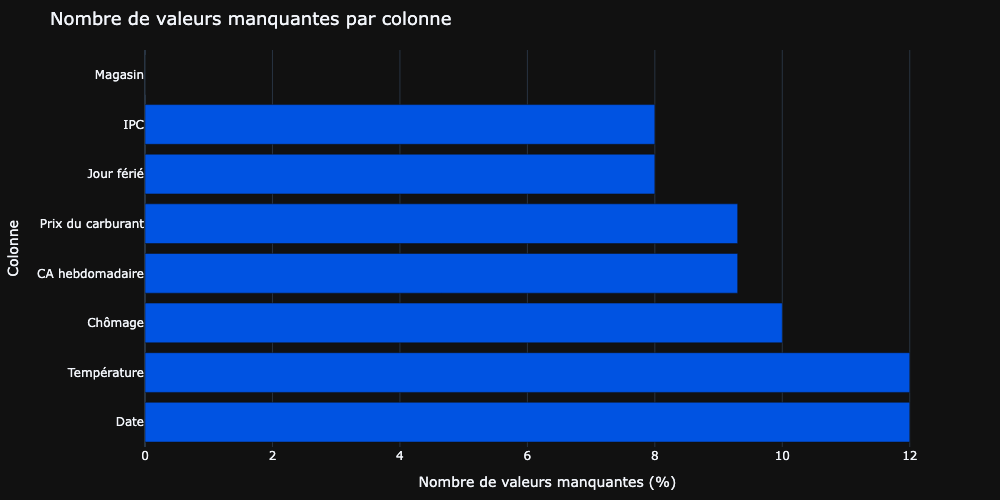

In [7]:
print("Nombre de valeurs manquantes par colonne :\n")
missing_values = pd.DataFrame(sales.isna().sum()).rename(columns={0: "Nombre de valeurs manquantes"})
missing_values = missing_values.sort_values("Nombre de valeurs manquantes", ascending=False)
missing_values["Nombre de valeurs manquantes (%)"] = missing_values["Nombre de valeurs manquantes"].div(nb_row).mul(100).round(1)
missing_values = missing_values.rename(index=TRANSLATE_VAR)
print(missing_values.to_string() + "\n")

nb_incomplete_row = (sales.isna().sum(axis=1) > 0).sum()
ratio_incomplete_row = nb_incomplete_row / nb_row
print(
    "Nombre de lignes avec au moins une valeur manquante :" +
    f"{nb_incomplete_row} / {nb_row} ({ratio_incomplete_row:.1%})\n".rjust(28)
)

fig = px.bar(
    missing_values,
    y=missing_values.index,
    x="Nombre de valeurs manquantes (%)",
    orientation="h",
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Nombre de valeurs manquantes par colonne",
)
fig.update_xaxes(title_text="Nombre de valeurs manquantes (%)")
fig.update_yaxes(title_text="Colonne")
fig_name = "Nombre de valeurs manquantes par colonne"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

---

Nous remarquons qu'il y a entre 8 et 12% de valeurs manquantes pour chaque colonne, à l'exception de la colonne `Store`, qui est complète.
Par ailleurs, la moitié des lignes ont au moins une valeur manquante.
En particulier, nous observons 14 lignes avec des valeurs manquantes dans la colonne `Weekly_Sales`.
Ces lignes devront être retirées avant l'entraînement des modèles.
En effet, toute imputation de la variable cible est formellement interdite selon Jedha, afin d'éviter un biais.

En revanche, nous décidons de maintenir ces lignes pour conduire l'EDA car :
- pour les analyses ne portant pas sur `Weekly_Sales`: cela permet d'avoir une vue complète des features disponibles.
- pour les analyses impliquant `Weekly_Sales` : les lignes sont automatiquement écartées par Pandas dans le calcul des corrélations, des distributions, des moyennes, etc. Il n'y a donc pas d'impact.

### 1.3 EDA

**Rappel :** Le jeu de données utilisé pour l'EDA comporte 150 lignes. Les 14 lignes où la variable cible est manquante sont conservées.

Nous extrayons les informations composant la date afin d'en tirer une analyse. Ces variables seront créées dans le pipeline de preprocessing.

In [8]:
sales_eda = sales.copy()
sales_eda["Date"] = pd.to_datetime(sales_eda["Date"], format="%d-%m-%Y")
sales_eda["Year"] = sales_eda["Date"].dt.year
sales_eda["Month"] = sales_eda["Date"].dt.month
sales_eda["Day"] = sales_eda["Date"].dt.day
sales_eda["Day_of_week"] = 1 + sales_eda["Date"].dt.dayofweek
sales_eda["Week_of_year"] = sales_eda["Date"].dt.isocalendar().week
sales_eda["sin_week_of_year"] = sales_eda["Week_of_year"].apply(lambda x: sin(2 * pi * x / 52))
sales_eda["cos_week_of_year"] = sales_eda["Week_of_year"].apply(lambda x: cos(2 * pi * x / 52))

In [9]:
print(sales_eda["Day_of_week"].value_counts(dropna=False).reset_index().to_string(index=False))

 Day_of_week  count
         5.0    132
         NaN     18


Pour les 132 lignes possédant une date, toutes tombent un vendredi. Par conséquent, il est **inutile de garder la variable `Day_of_week`.**

#### 1.3.1 Statistiques globales

In [10]:
sales_eda.describe(exclude=["datetime64"]).round(2)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,Day_of_week,Week_of_year,sin_week_of_year,cos_week_of_year
count,150.00,136.00,138.00,132.00,136.00,138.00,135.00,132.00,132.00,132.00,132.0,132.0,132.00,132.00
mean,9.87,1249535.83,0.08,61.40,3.32,179.90,7.60,2010.86,6.39,16.52,5.0,25.68,0.04,-0.12
std,6.23,647463.04,0.27,18.38,0.48,40.27,1.58,0.81,3.21,8.31,0.0,14.0,0.69,0.71
min,1.00,268929.03,0.00,18.79,2.51,126.11,5.14,2010.00,1.00,1.00,5.0,1.0,-1.00,-1.00
25%,4.00,605075.72,0.00,45.59,2.85,131.97,6.60,2010.00,4.00,10.00,5.0,15.0,-0.66,-0.82
50%,9.00,1261423.86,0.00,62.98,3.45,197.91,7.47,2011.00,6.00,17.00,5.0,25.0,0.12,-0.24
75%,15.75,1806386.20,0.00,76.34,3.71,214.93,8.15,2012.00,9.00,24.00,5.0,36.25,0.75,0.66
max,20.00,2771397.17,1.00,91.65,4.19,226.97,14.31,2012.00,12.00,31.00,5.0,52.0,1.00,1.00


#### 1.3.2 Distribution des variables

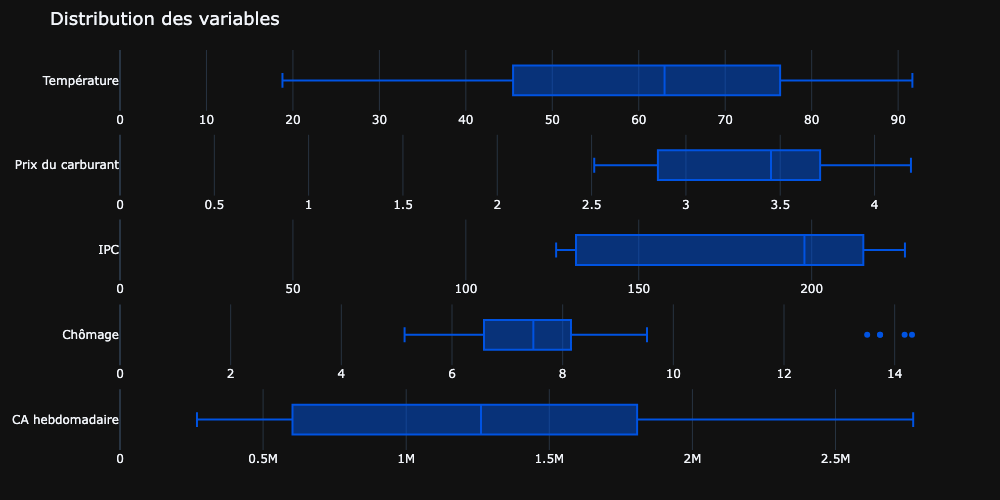

In [11]:
fig = make_subplots(rows=5, cols=1)

for i, col in enumerate([TRANSLATE_VAR[c] for c in ["Temperature", "Fuel_Price", "CPI", "Unemployment", TARGET_VAR]], start=1):
    z = sales_eda.rename(columns=TRANSLATE_VAR)[col]
    fig.add_trace(
        go.Box(
            x=z,
            marker=dict(color=DEFAULT_COLOR),
            name=col
        ),
        row=i,
        col=1
    )
    max_col=float(z.max())
    max_x=round(max_col + 0.5 * 10 ** (log10(max_col) - 1), -int(log10(max_col)) + 1)
    fig.update_xaxes(range=[0, max_x], row=i, col=1)

fig.update_layout(
    title="Distribution des variables",
    height=500,
    showlegend=False,
)

fig_name = "Distribution des variables"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Nous notons la présence de quatre valeurs aberrantes pour la variable liée au taux de chômage. Les autres variables n'en ont pas.

#### 1.3.3 Matrices de corrélation

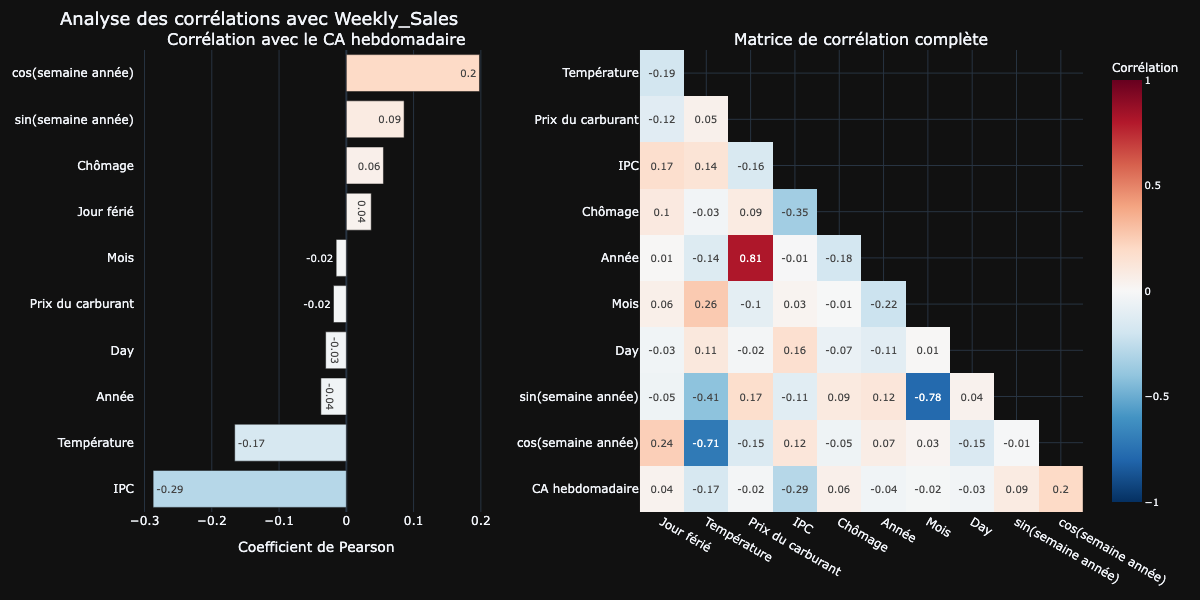

In [12]:
corr_columns = [
    "Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "Year", "Month", "Day", "sin_week_of_year", "cos_week_of_year",
    TARGET_VAR
]
corr_pearson = sales_eda[corr_columns].corr()
corr_pearson = corr_pearson.rename(columns=TRANSLATE_VAR, index=TRANSLATE_VAR)
corr_pearson_row = corr_pearson[TRANSLATE_VAR[TARGET_VAR]].drop(TRANSLATE_VAR[TARGET_VAR]).sort_values(ascending=True)
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=0)  # masque le triangle supérieur et la diagonale
corr_pearson = corr_pearson.mask(mask).iloc[1:, :-1]

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.45, 0.55],
    subplot_titles=(
        "Corrélation avec le CA hebdomadaire",
        "Matrice de corrélation complète",
    ),
    horizontal_spacing=0.15,
)

fig.add_trace(
    go.Bar(
        x=corr_pearson_row.values,
        y=corr_pearson_row.index,
        orientation="h",
        text=corr_pearson_row.round(2).values,
        textposition="auto",
        marker=dict(
            color=corr_pearson_row.values,
            colorscale="RdBu_r",
            cmin=-1,
            cmax=1,
            cmid=0,
            showscale=False,  # on cache cette colorbar pour n'en garder qu'une
        ),
        hovertemplate="%{y} : %{x:.2f}<extra></extra>",
    ),
    row=1,
    col=1,
)

text_values = corr_pearson.round(2).astype(object).where(corr_pearson.notna(), "")
fig.add_trace(
    go.Heatmap(
        z=corr_pearson.values,
        x=corr_pearson.columns,
        y=corr_pearson.index,
        text=text_values.values,
        texttemplate="%{text}",
        colorscale="RdBu_r",
        zmin=-1,
        zmax=1,
        zmid=0,
        hovertemplate="%{y} vs %{x}<br>corr = %{z:.2f}<extra></extra>",
        colorbar=dict(title="Corrélation", x=1.02),
    ),
    row=1,
    col=2,
)

fig.update_xaxes(title_text="Coefficient de Pearson", row=1, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=2)  # diagonale en haut à gauche

fig.update_layout(
    title_text="Analyse des corrélations avec Weekly_Sales",
    showlegend=False,
    height=600,
    width=1200
)

fig_name = "Analyse des corrélations avec Weekly_Sales"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

La matrice de corrélation de Pearson, montrant la linéarité entre les variables, indique que :
- Aucune variable n'est fortement corrélée avec le CA hebdomadaire.
- La variable la plus corrélée est l'IPC, en valeur négative, avec -0,29. Il s'agit donc d'une corrélation à la limite basse du modéré. Les observations associées à un IPC élevé tendent à présenter des ventes plus faibles.
- La deuxième variable la plus corrélée est la température, avec -0,17, donc faiblement corrélée.
- Les autres variables sont très faiblement corrélées, voire décorrélées. En particulier, le booléen indiquant un jour férié est quasi décorrélé de la cible. Cela peut vouloir dire que le nombre de lignes avec jour férié est trop faible ou que les ventes sont éventuellement décalées avant ces jours.
- Une multicolinéarité forte apparaît entre l'année et le prix des carburants (0,81), reflétant la hausse du prix du carburant sur la période étudiée. C'est le seul couple problématique en intensité, mais il suffit à compliquer l'interprétation des coefficients d'une régression linéaire non régularisée.
- Des corrélations modérées complètent le tableau, toutes cohérentes économiquement ou physiquement : IPC / chômage à -0,35, température / mois à 0,26, jour férié / température à -0,19 (les fériés majeurs tombent en hiver).
- Les variables `sin_week_of_year` et `cos_week_of_year` ont été créées pour tester un encodage cyclique de la saisonnalité. Elles s'avèrent fortement corrélées avec le mois (-0,78) et la température (-0,71) : les conserver introduirait beaucoup de redondance pour un gain prédictif marginal. Leur retrait simplifie le modèle, stabilise les coefficients et facilite l'interprétation, sans perte d'information substantielle puisque la saisonnalité reste captée par le mois et la température.

Synthèse et conséquence pour la suite :
- L'IPC sera vraisemblablement la variable la plus influente dans le modèle, suivie de la température. Les autres variables auront probablement des coefficients faibles, voire poussés vers zéro par la régularisation.
- Les colonnes `sin_week_of_year` et `cos_week_of_year` seront supprimées.

#### 1.3.4 Nombre de lignes par magasin dans le jeu de données

Statistiques sur le nombre de lignes par magasin :
count    20.000000
mean      7.500000
std       2.856203
min       3.000000
25%       5.000000
50%       8.000000
75%       9.000000
max      15.000000



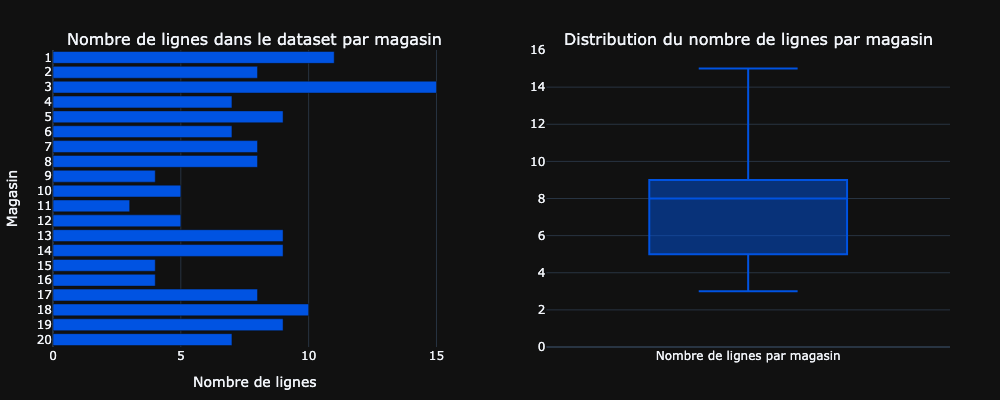

In [13]:
nb_row_per_store = sales_eda.value_counts("Store").rename("Nombre de lignes").reset_index()
nb_row_per_store["Magasin"] = nb_row_per_store["Store"].astype(int)
nb_row_per_store = nb_row_per_store.sort_values("Magasin", ascending=False)
nb_row_per_store["Magasin"] = nb_row_per_store["Magasin"].astype(str)

print(
    "Statistiques sur le nombre de lignes par magasin :\n" +
    nb_row_per_store["Nombre de lignes"].describe().to_string() + "\n"
)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Nombre de lignes dans le dataset par magasin", "Distribution du nombre de lignes par magasin"]
)


fig.add_trace(
    go.Bar(
        x=nb_row_per_store["Nombre de lignes"],
        y=nb_row_per_store["Magasin"],
        orientation="h",
        marker=dict(color=DEFAULT_COLOR),
    ),
    row=1,
    col=1
)
fig.update_xaxes(title_text="Nombre de lignes", row=1, col=1)
fig.update_yaxes(title_text="Magasin", row=1, col=1)


fig.add_trace(
    go.Box(
        y=nb_row_per_store["Nombre de lignes"],
        marker=dict(color=DEFAULT_COLOR),
        name="Nombre de lignes par magasin",
    ),
    row=1,
    col=2
)
max_col = float(nb_row_per_store["Nombre de lignes"].max())
max_y = int(max_col + 0.5) + 1
fig.update_yaxes(range=[0, max_y], row=1, col=2)

fig.update_layout(
    height=400,
    showlegend=False
)

fig_name = "Nombre de lignes par magasin"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

L'échantillonnage est très déséquilibré. Avec une moyenne de 7,5 lignes par magasin et un écart-type de 2,86,
certains magasins ne sont représentés que par 3 observations quand d'autres en ont 15 (rapport de 1 à 5).
Cela pose plusieurs problèmes :
- Les moyennes par magasin pour les plus petits effectifs sont peu fiables (3 semaines ne sont pas représentatives d'une année).
- Le modèle apprendra mieux les magasins sur-représentés.
- Le découpage train/test risque d'aboutir à des magasins absents du train ou du test, ce qui poserait un vrai problème avec un encodage `Store` en catégoriel.

Implications pour la modélisation :
1. **Stratifier le split train/test sur `Store`** pour garantir que chaque magasin apparaît dans les deux ensembles.
2. **Anticiper une variance élevée des coefficients par magasin** dans la régression. Avec 20 magasins en encodage one-hot, on ajoute 19 colonnes pour 150 lignes, ce qui est beaucoup. C'est un argument supplémentaire en faveur de Ridge.
3. Un **échantillon** aussi **déséquilibré** et restreint par magasin **fragilise la généralisation**.

#### 1.3.5 Chiffre d'affaires

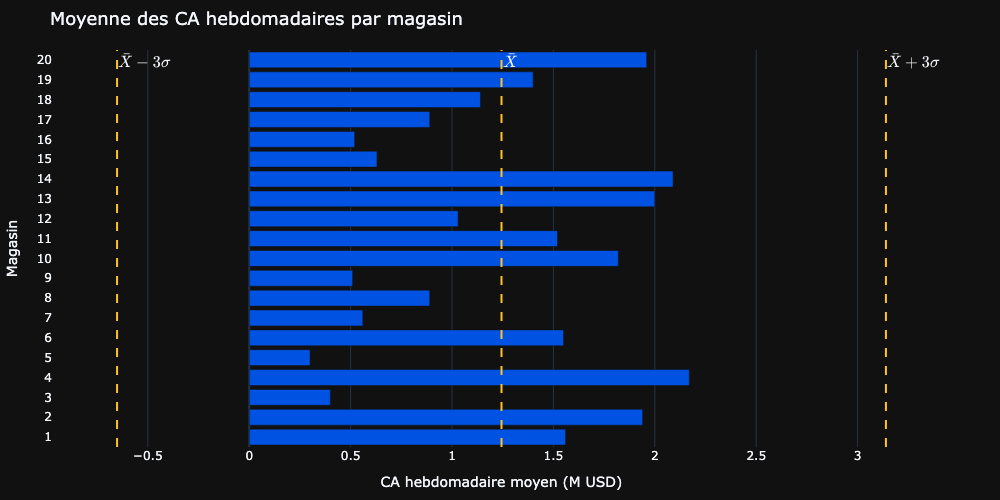

In [14]:
mean_weekly_shares_per_store = sales_eda.groupby("Store")[TARGET_VAR].mean().div(1e6).round(2).reset_index().rename(columns=TRANSLATE_VAR)
mean_weekly_shares_per_store["Magasin"] = mean_weekly_shares_per_store["Magasin"].astype(int).astype(str)
mean_shares = mean_weekly_shares_per_store["CA hebdomadaire"].mean()
std_shares = mean_weekly_shares_per_store["CA hebdomadaire"].std()

fig = px.bar(
    mean_weekly_shares_per_store,
    y="Magasin",
    x="CA hebdomadaire",
    orientation="h",
    color_discrete_sequence=[DEFAULT_COLOR],
    title="Moyenne des CA hebdomadaires par magasin",
)
fig.update_xaxes(title_text="CA hebdomadaire moyen (M USD)")
fig.update_yaxes(title_text="Magasin")

fig.add_vline(
    x=mean_shares,
    line_dash='dash',
    line_color=ALT_COLOR,
    annotation_text=r"$\bar{X}$"
)
fig.add_vline(
    x=mean_shares - 3 * std_shares,
    line_dash='dash',
    line_color=ALT_COLOR,
    annotation_text=r"$\bar{X} - 3 \sigma$"
)

fig.add_vline(
    x=mean_shares + 3 * std_shares,
    line_dash='dash',
    line_color=ALT_COLOR,
    annotation_text=r"$\bar{X} + 3 \sigma$"
)

fig.update_xaxes(range=[mean_shares - 3.5 * std_shares, mean_shares + 3.5 * std_shares])

fig_name = "Moyenne des CA hebdomadaires par magasin"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Nous notons une forte hétérogénéité du CA hebdomadaire moyen entre les magasins.
Il varie de 0,3M USD (magasin 5) à 2,17 M$ (magasin 4), soit un rapport de 1 à 7.
Cette dispersion est considérable et confirme que `Store` est une variable explicative potentiellement très forte,
justifiant son traitement en catégoriel comme prévu par le cahier des charges.

Nombre de lignes avec jour(s) férié(s) :
 Jour férié  Total
        0.0    127
        NaN     12
        1.0     11



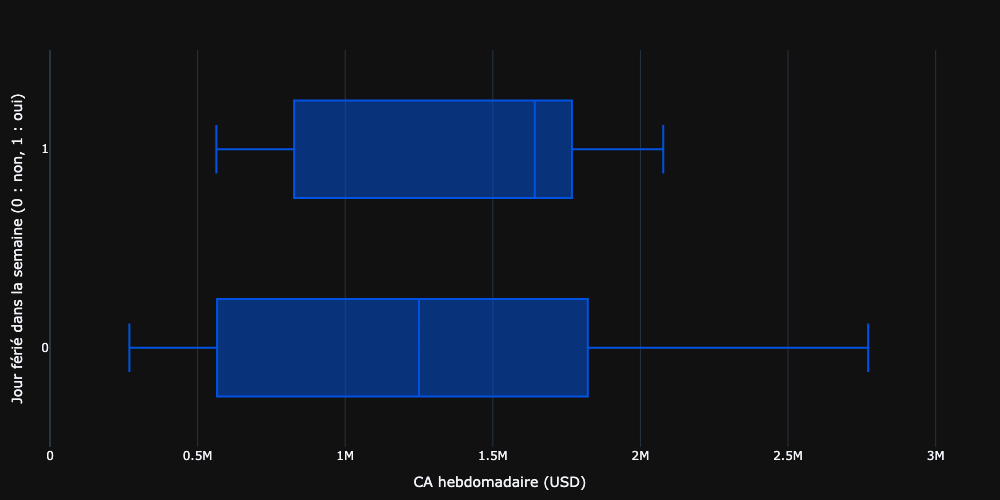

In [15]:
print(
    "Nombre de lignes avec jour(s) férié(s) :\n" +
    (
        sales_eda
        .value_counts("Holiday_Flag", dropna=False)
        .reset_index()
        .rename(columns=TRANSLATE_VAR)
        .rename(columns={"count": "Total"})
        .to_string(index=False)
    ) + "\n"
)

fig = px.box(
    sales_eda[~sales_eda["Holiday_Flag"].isna()].rename(columns=TRANSLATE_VAR),
    y="Jour férié",
    x="CA hebdomadaire",
    orientation="h",
    color_discrete_sequence=[DEFAULT_COLOR],
)
fig.update_xaxes(range=[0 , 1.1 * sales_eda[TARGET_VAR].max()])
fig.update_xaxes(title_text="CA hebdomadaire (USD)")
fig.update_yaxes(title_text="Jour férié dans la semaine (0 : non, 1 : oui) ")
fig_name = "CA hebdomadaire en fonction de jour ferie"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Le jeu de données possède 12 lignes pour lesquelles la variable `Holiday_flag` n'a pas de valeur,
soit une unité de plus que le nombre de lignes indiquant un jour férié.
La très large majorité des lignes (127 / 150) indique une absence de jour férié dans la semaine considérée.

Les boîtes à moustaches indiquent différentes distributions de CA selon la présence d'un jour férié dans la semaine.

Pour une semaine sans jour férié, la distribution semble quasi normale.
La médiane (~1,25M USD) est proche du milieu de l'intervalle $[Q1 ; Q3]$.
Il existe une dissymétrie, par rapport à la médiane, de Q1 et Q4, montrant pour Q4 que des CA peuvent fortement grimper sur certaines semaines.
Cela peut s'expliquer par la présence de soldes ou d'événements majeurs hors jours fériés (exemple : événément sportif).

La distribution des CA pour les semaines avec jour(s) férié(s) est fortement dissymétrique.
L'écart interquartile inférieur (Q2 - Q1) est très étendu (~0,81M USD) alors que l'écart interquartile supérieur (Q3 - Q2) est très restreint (~0,13M USD).
Par ailleurs, la médiane est plus grande que pour les semaines sans jour férié (~1,64M USD, soit +31%).

Dans les deux cas, aucune valeur aberrante n'est trouvée.

### 1.4 Pré-traitements avec Pandas

#### 1.4.1 Sélections des variables

In [16]:
# Nous reprenons le dataframe utilisé pour l'EDA et nous supprimons les variables inutiles.
sales = sales_eda.copy()
sales = sales.drop(columns=["Date", "Day_of_week", "Week_of_year", "sin_week_of_year", "cos_week_of_year"])
sales.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0
2,17.0,NaN,0.0,NaN,NaN,130.719581,5.936,2012.0,7.0,27.0
3,11.0,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0


#### 1.4.2 Imputation des valeurs manquantes pour les variables explicatives

L'imputation des valeurs manquantes pour les variables explicatives est exclue des pré-traitements de cette partie.
En effet, **imputer les valeurs manquantes avant d'effectuer la séparation** du jeu de données global en deux jeux de données
séparés dédiés à l'entraînement et au test **introduirait une fuite de données**.

Cependant, nous devons nous assurer au préalable que les variables n'aient pas un taux de valeurs manquantes trop élevé.
Ici, il est au maximum de 12%, ce qui est acceptable.

In [17]:
nb_row = len(sales)
print("Taux de valeurs manquantes par colonne (%) :")
print(sales.isna().sum().div(nb_row).mul(100).round(1).sort_values(ascending=False).rename(index=TRANSLATE_VAR).to_string())

Taux de valeurs manquantes par colonne (%) :
Température          12.0
Année                12.0
Mois                 12.0
Day                  12.0
Chômage              10.0
CA hebdomadaire       9.3
Prix du carburant     9.3
Jour férié            8.0
IPC                   8.0
Magasin               0.0


#### 1.4.3 Valeurs manquantes pour la variable cible

In [18]:
print(
    "Lignes avec valeurs cibles manquantes :\n" +
    sales[sales[TARGET_VAR].isna()].to_string() + "\n"
)
nb_row = len(sales)
sales = sales.dropna(subset=[TARGET_VAR])
print(f"Lignes avant :    {nb_row}")
print(f"Lignes après :    {len(sales)}")
print(f"Lignes retirées : {nb_row - len(sales)}")

Lignes avec valeurs cibles manquantes :
     Store  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment    Year  Month   Day
2     17.0           NaN           0.0          NaN         NaN  130.719581         5.936  2012.0    7.0  27.0
19     3.0           NaN           0.0        72.38       3.630  225.251202         6.664  2012.0    5.0  18.0
31     5.0           NaN           1.0          NaN       3.129  220.117823         6.300  2011.0   12.0  30.0
57     4.0           NaN           0.0          NaN       2.980  127.191774         6.510  2011.0    1.0   7.0
69    20.0           NaN           0.0        50.49       2.854  204.201755         8.187  2010.0    3.0  26.0
71    20.0           NaN           1.0        76.36       3.911  215.218957           NaN  2012.0    9.0   7.0
77     3.0           NaN           0.0        88.07       3.682         NaN         7.567  2011.0    7.0  29.0
84     8.0           NaN           0.0        76.14       2.577  214.894

#### 1.4.4 Valeurs aberrantes

**Note méthodologique :** le filtrage des valeurs aberrantes est appliqué ici, avant la séparation train/test demandée en 1.5.1. Stricto sensu, cela introduit une légère fuite de données : les statistiques utilisées pour définir les bornes ($\bar{X}$ et $\sigma$) sont calculées sur l'ensemble du jeu, y compris les futures observations de test. La rigueur méthodologique voudrait que ces bornes soient estimées sur le seul jeu d'entraînement puis appliquées au test. Nous suivons cependant l'ordre des étapes imposé par le cahier des charges Jedha, qui place ce filtrage dans la phase Pandas en amont du pipeline scikit-learn.

Les boîtes à moustaches utilisées en 1.3.2 reposent sur le critère $[Q1 - 1{,}5 \ IQR \ ; \ Q3 + 1{,}5 \ IQR]$ et ne servent ici qu'à repérer visuellement les valeurs extrêmes : elles signalent quatre valeurs aberrantes sur `Unemployment` uniquement. Pour le filtrage effectif, nous appliquons le critère imposé par Jedha, $[\bar{X} - 3\sigma \ ; \ \bar{X} + 3\sigma]$, plus permissif.

In [19]:
columns_to_filter = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
z_scores = (sales[columns_to_filter] - sales[columns_to_filter].mean()) / sales[columns_to_filter].std()
mask_not_outliers = ((z_scores.abs() <= 3) | z_scores.isna()).all(axis=1).astype(bool)
print(
    "Lignes avec valeurs aberrantes :\n" +
    sales[~mask_not_outliers].to_string() + "\n"
)
nb_row = len(sales)
sales = sales[mask_not_outliers]
print(f"Lignes avant :    {nb_row}")
print(f"Lignes après :    {len(sales)}")
print(f"Lignes retirées : {nb_row - len(sales)}")

Lignes avec valeurs aberrantes :
     Store  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment    Year  Month   Day
30    12.0    1021154.48           0.0        68.40       4.193  129.044433        13.736  2011.0    5.0   6.0
62    12.0    1295605.35           0.0        52.77       3.236  126.879484        14.313  2010.0   12.0  17.0
68    12.0     955913.68           0.0        91.04       3.701  129.201581        13.503  2011.0    8.0  12.0
93    12.0     964332.51           0.0          NaN       4.087  129.062355        13.736  2011.0    5.0  27.0
135   12.0     903119.03           1.0        83.63       3.044  126.114581        14.180  2010.0    9.0  10.0

Lignes avant :    136
Lignes après :    131
Lignes retirées : 5


Les 5 lignes retirées correspondent aux valeurs aberrantes de taux de chômage (13 à 14%) repérées précédemment dans les boîtes à moustaches.

#### 1.4.5 Modification des types

In [20]:
sales["Store"] = sales["Store"].astype(int)
sales["Holiday_Flag"] = sales["Holiday_Flag"].astype("Int64")
sales["Year"] = sales["Year"].astype("Int64")
sales["Month"] = sales["Month"].astype("Int64")
sales["Day"] = sales["Day"].astype("Int64")

### 1.5 Pré-traitements avec scikit-learn

Objectif : construire un pipeline scikit-learn complet, robuste et reproductible, prêt à recevoir n'importe quel modèle linéaire en Partie 2.

#### 1.5.1 Séparation train/test stratifiée

On stratifie par la variable `Store` afin de garantir une représentation équilibrée des magasins entre les deux ensembles, sachant qu'il s'agit de la principale source d'hétérogénéité du jeu de données.

In [21]:
# Séparation explicative / cible
X = sales.drop(columns=[TARGET_VAR])
y = sales[TARGET_VAR]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=X["Store"],
    random_state=RANDOM_STATE,
)

print(f"X_train : {X_train.shape}    y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}     y_test  : {y_test.shape}")

X_train : (104, 9)    y_train : (104,)
X_test  : (27, 9)     y_test  : (27,)


#### 1.5.2 Définition du ColumnTransformer

Trois sous-pipelines sont construits selon le type de variable et la stratégie d'imputation retenue :
- catégorielles : imputation par le mode puis encodage one-hot (`drop="first"` pour éviter la colinéarité parfaite),
- numériques continues : imputation par la médiane puis standardisation,
- numériques temporelles : imputation par le mode puis standardisation.
La standardisation est ajoutée pour préparer la voie aux modèles régularisés de la Partie 3, dont les pénalités sont sensibles à l'échelle des variables.

In [22]:
# Définition des groupes de colonnes
categorical_features = ["Store", "Holiday_Flag"]
numeric_median_features = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
numeric_mode_features = ["Year", "Month", "Day"]


def build_preprocessor():
    """Build the ColumnTransformer that applies group-specific preprocessing."""

    # Sous-pipeline pour variables catégorielles
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop="first", handle_unknown="error")),
        ]
    )

    # Sous-pipeline pour variables numériques imputées par la médiane
    numeric_median_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    # Sous-pipeline pour variables numériques imputées par le mode
    numeric_mode_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("scaler", StandardScaler()),
        ]
    )

    # Assemblage dans un ColumnTransformer
    return ColumnTransformer(
        transformers=[
            ("cat",        categorical_pipeline,    categorical_features),
            ("num_median", numeric_median_pipeline, numeric_median_features),
            ("num_mode",   numeric_mode_pipeline,   numeric_mode_features),
        ]
    )

#### 1.5.3 Assemblage et test de bout en bout

Le pipeline complet est construit via une fonction `build_pipeline` qui accepte n'importe quel estimateur scikit-learn (compatible avec l'API `fit`/`predict`). Ainsi, la même chaîne de pré-traitements pourra être réutilisée à l'identique avec `LinearRegression`, `Ridge` ou `Lasso` dans les parties suivantes.

In [23]:
def build_pipeline(model):
    """Build the full preprocessing-and-modeling pipeline for any linear model."""
    return Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("model", model),
    ])


# Test de bout en bout avec une régression linéaire simple
test_pipeline = build_pipeline(LinearRegression())
test_pipeline.fit(X_train, y_train)

# Vérification des dimensions après transformation
X_train_transformed = test_pipeline.named_steps["preprocessor"].transform(X_train)
print(f"Forme de X_train après pré-traitements : {X_train_transformed.shape}")
print(f"Nombre de features finales : {X_train_transformed.shape[1]}\n")

# Score R² pour valider que le pipeline tourne de bout en bout
print(f"R² train : {test_pipeline.score(X_train, y_train):.4f}")
print(f"R² test  : {test_pipeline.score(X_test,  y_test):.4f}")

Forme de X_train après pré-traitements : (104, 26)
Nombre de features finales : 26

R² train : 0.9732
R² test  : 0.9524


## Partie 2 - Régression linéaire

### 2.1 Entraînement du modèle baseline

Le pipeline de pré-traitements défini en 1.5 est réutilisé tel quel et complété par une `LinearRegression` non régularisée. Ce modèle, simple et rapide à ajuster, sert de référence à laquelle seront comparés les modèles régularisés de la Partie 3.

In [24]:
# Construction et entrainement du pipeline baseline
baseline_pipeline = build_pipeline(LinearRegression())
baseline_pipeline.fit(X_train, y_train)

# Prédictions sur les deux ensembles
y_train_pred = baseline_pipeline.predict(X_train)
y_test_pred = baseline_pipeline.predict(X_test)

### 2.2 Évaluation des performances

Trois métriques complémentaires sont retenues pour ce problème de régression :
- **R²** : part de la variance de la cible expliquée par le modèle (indicateur sans unité, comparable d'un modèle à l'autre),
- **RMSE** : racine de l'erreur quadratique moyenne, dans l'unité de la cible et pénalisante pour les grosses erreurs,
- **MAE** : erreur absolue moyenne, plus robuste aux valeurs extrêmes et facile à interpréter.
L'évaluation est faite simultanément sur les ensembles d'entraînement et de test, afin de détecter un éventuel sur-apprentissage par l'écart entre les deux.

In [25]:
# Calcul des métriques sur train et test
def compute_metrics(y_true, y_pred):
    """Return a dict of regression metrics for a given pair of arrays."""
    return {
        "R²":   r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE":  mean_absolute_error(y_true, y_pred),
    }


baseline_scores = pd.DataFrame({
    "Train": compute_metrics(y_train, y_train_pred),
    "Test":  compute_metrics(y_test,  y_test_pred),
})

# Mise en forme : 4 décimales pour le R², 2 pour les erreurs (en dollars)
baseline_scores_display = baseline_scores.copy()
baseline_scores_display.loc["R²"] = baseline_scores.loc["R²"].round(4)
baseline_scores_display.loc["RMSE"] = baseline_scores.loc["RMSE"].round(2)
baseline_scores_display.loc["MAE"] = baseline_scores.loc["MAE"].round(2)

print("Performances du modèle baseline :\n")
print(baseline_scores_display.to_string())

Performances du modèle baseline :

            Train         Test
R²         0.9732       0.9524
RMSE  104645.8200  155737.4300
MAE    78607.5000  110653.6400


Le R² test (0,9524) reste proche du R² train (0,9732), avec un écart limité à environ 2%. En revanche, les erreurs absolues mettent en évidence un sur-apprentissage plus marqué : la RMSE test (≈156k USD) est supérieure d'environ 49% à celle du train (≈105k USD), et la MAE test (≈111k USD) d'environ 41%. Rapportée à la moyenne des ventes hebdomadaires (≈ 1,48M USD, ordre de grandeur de l'ordonnée à l'origine), la MAE test représente environ 7% d'erreur relative.

### 2.3 Analyse graphique des prédictions

Une comparaison visuelle des valeurs prédites face aux valeurs observées permet de juger qualitativement de la qualité de l'ajustement. Plus les points sont proches de la droite d'équation $y = x$, meilleure est la prédiction.

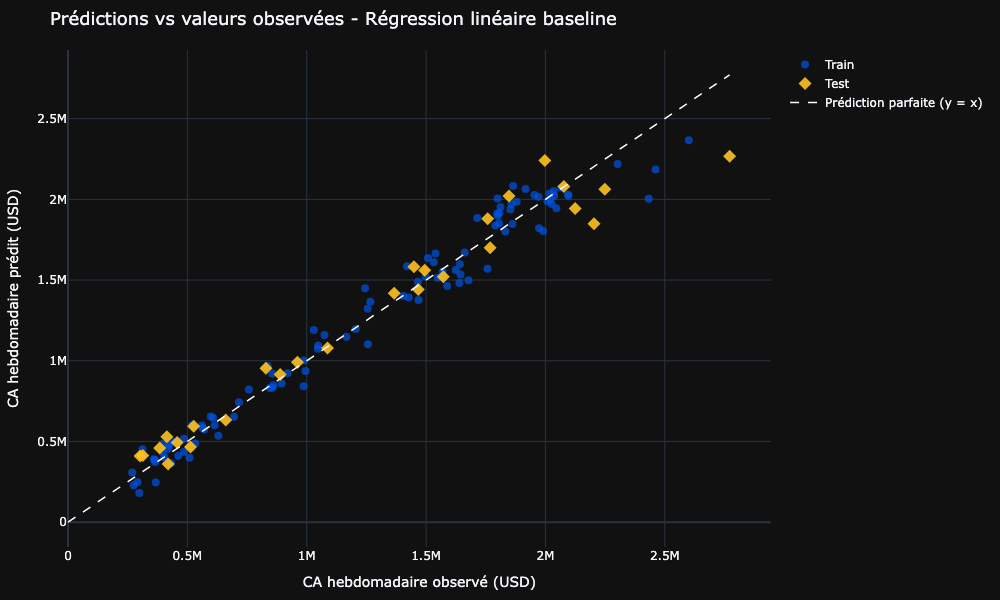

In [26]:
# Bornes communes pour la droite y = x
min_val = min(0, y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())

fig = go.Figure()

# Nuage des prédictions sur l'ensemble d'entrainement
fig.add_trace(
    go.Scatter(
        x=y_train,
        y=y_train_pred,
        mode="markers",
        name="Train",
        marker=dict(color=DEFAULT_COLOR, size=8, opacity=0.7),
    )
)

# Nuage des prédictions sur l'ensemble de test
fig.add_trace(
    go.Scatter(
        x=y_test, y=y_test_pred,
        mode="markers",
        name="Test",
        marker=dict(color=ALT_COLOR, size=10, opacity=0.9, symbol="diamond"),
    )
)

# Droite de référence y = x (prédiction parfaite)
fig.add_trace(
    go.Scatter(
        x=[min_val, max_val], y=[min_val, max_val],
        mode="lines",
        name="Prédiction parfaite (y = x)",
        line=dict(color="white", dash="dash", width=1.5),
    )
)

fig.update_layout(
    title="Prédictions vs valeurs observées - Régression linéaire baseline",
    xaxis_title="CA hebdomadaire observé (USD)",
    yaxis_title="CA hebdomadaire prédit (USD)",
    height=600,
)
fig_name = "Prédictions vs valeurs observees pour baseline"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

Les points test (jaune) s'écartent visiblement plus de la diagonale que les points train (bleu), ce qui est cohérent avec la dégradation des métriques. Quelques observations test affichent des erreurs supérieures à 1M USD, signe que le modèle généralise mal sur certains profils.

### 2.4 Diagnostic des résidus

Une régression linéaire repose sur trois hypothèses qu'il faut vérifier a posteriori :
- **linéarité** : les résidus ne doivent pas présenter de structure systématique en fonction des valeurs prédites,
- **homoscédasticité** : la dispersion des résidus doit rester constante sur tout l'intervalle des prédictions,
- **normalité** : la distribution des résidus doit être approximativement gaussienne.

Le graphique de gauche teste la linéarité et l'homoscédasticité, celui de droite (QQ-plot) teste la normalité.

In [27]:
# Calcul des résidus
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

# Vérification : la moyenne des résidus doit être proche de zéro
print("Moyenne des résidus :")
print(f"  Train : {residuals_train.mean():>10,.2f} USD")
print(f"  Test  : {residuals_test.mean():>10,.2f} USD")

Moyenne des résidus :
  Train :      -0.00 USD
  Test  :   1,462.70 USD


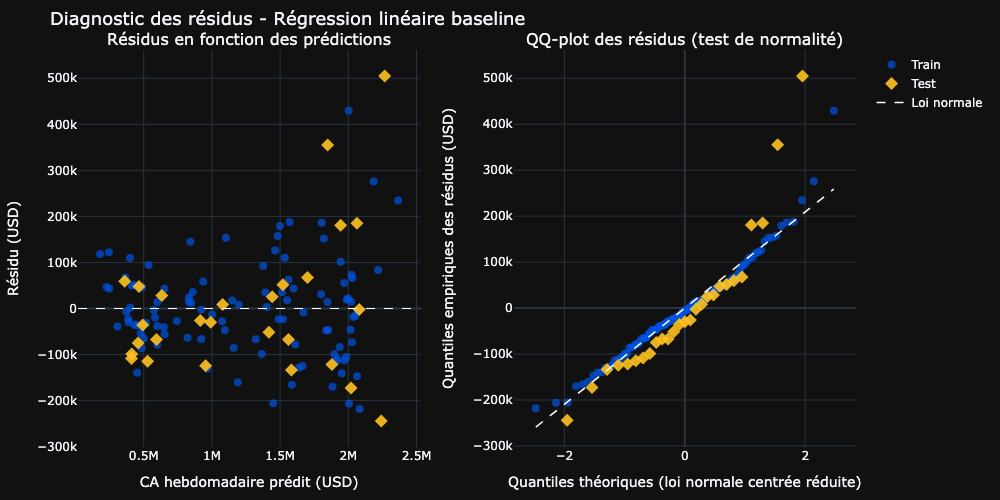

In [28]:
# Préparation du QQ-plot via scipy
qq_train = probplot(residuals_train, dist="norm")
qq_test = probplot(residuals_test, dist="norm")

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Résidus en fonction des prédictions",
        "QQ-plot des résidus (test de normalité)",
    ),
    horizontal_spacing=0.12,
)

# Graphique de gauche : résidus vs prédictions
fig.add_trace(
    go.Scatter(
        x=y_train_pred, y=residuals_train,
        mode="markers", name="Train",
        marker=dict(color=DEFAULT_COLOR, size=8, opacity=0.7),
    ),
    row=1, col=1,
)
fig.add_trace(
    go.Scatter(
        x=y_test_pred, y=residuals_test,
        mode="markers", name="Test",
        marker=dict(color=ALT_COLOR, size=10, opacity=0.9, symbol="diamond"),
    ),
    row=1, col=1,
)
fig.add_hline(y=0, line=dict(color="white", dash="dash", width=1), row=1, col=1)

# Graphique de droite : QQ-plot
fig.add_trace(
    go.Scatter(
        x=qq_train[0][0], y=qq_train[0][1],
        mode="markers", showlegend=False,
        marker=dict(color=DEFAULT_COLOR, size=8, opacity=0.7),
    ),
    row=1, col=2,
)
fig.add_trace(
    go.Scatter(
        x=qq_test[0][0], y=qq_test[0][1],
        mode="markers", showlegend=False,
        marker=dict(color=ALT_COLOR, size=10, opacity=0.9, symbol="diamond"),
    ),
    row=1, col=2,
)
# Droite de référence ajustée sur le train
slope, intercept_qq = qq_train[1][0], qq_train[1][1]
qq_x = np.array([qq_train[0][0].min(), qq_train[0][0].max()])
fig.add_trace(
    go.Scatter(
        x=qq_x, y=slope * qq_x + intercept_qq,
        mode="lines", name="Loi normale",
        line=dict(color="white", dash="dash", width=1.5),
    ),
    row=1, col=2,
)

fig.update_xaxes(title_text="CA hebdomadaire prédit (USD)", row=1, col=1)
fig.update_yaxes(title_text="Résidu (USD)", row=1, col=1)
fig.update_xaxes(title_text="Quantiles théoriques (loi normale centrée réduite)", row=1, col=2)
fig.update_yaxes(title_text="Quantiles empiriques des résidus (USD)", row=1, col=2)

fig.update_layout(
    title="Diagnostic des résidus - Régression linéaire baseline",
    height=500,
)
fig_name = "Diagnostic des residus pour baseline"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

**Graphique de gauche (résidus vs prédictions) :**
- les résidus du train sont centrés sur zéro sur tout l'intervalle, sans courbure visible : l'hypothèse de linéarité tient,
- en revanche, l'amplitude des résidus augmente nettement avec la valeur prédite : pour des prédictions autour de 0,5M USD les résidus dépassent rarement ±200k USD, alors qu'au-delà de 1,5M USD certains dépassent ±400k USD. C'est un signe clair d'**hétéroscédasticité** : la dispersion de l'erreur n'est pas constante.

**Graphique de droite (QQ-plot) :**
- dans la partie centrale, les points train s'alignent correctement sur la droite de référence : la majorité des résidus se comporte comme une loi normale,
- aux deux extrémités, les points train s'écartent de la droite, plus fortement à droite qu'à gauche : la distribution des résidus a une queue droite plus lourde que la normale (quelques grosses erreurs positives plus fréquentes que ce que prédirait une gaussienne),
- les points test s'écartent davantage de la droite que les points train, ce qui prolonge le constat de sur-apprentissage déjà fait sur les métriques.

**Conséquence :**
L'hétéroscédasticité est la fragilité principale de ce modèle. Elle suggère qu'une **transformation logarithmique de la cible** (log(Weekly_Sales)) stabiliserait la variance et améliorerait probablement les performances, notamment sur les magasins à fort CA. Cette piste est documentée comme amélioration possible dans la conclusion du projet, mais sort du périmètre demandé par Jedha, qui impose une régression linéaire directe sur la cible brute.

### 2.5 Interprétation des coefficients

L'attribut `.coef_` du modèle donne le poids associé à chaque variable explicative. Quelques précautions d'interprétation :
- les **variables numériques** ayant été standardisées, leurs coefficients représentent l'effet d'une variation d'un écart-type sur les ventes hebdomadaires, exprimé en dollars,
- les **variables catégorielles** étant encodées en "one-hot" avec suppression de la première modalité, chaque coefficient mesure l'écart de ventes par rapport au magasin (ou au statut) de référence,
- les coefficients ne reflètent pas une causalité, mais une association statistique, conditionnelle aux autres variables du modèle.

In [29]:
def clean_feature_name(name):
    """Clean ColumnTransformer feature names for human-readable display."""
    # Suppression du préfixe du sous-pipeline
    for prefix in ("cat__", "num_median__", "num_mode__"):
        if name.startswith(prefix):
            name = name[len(prefix):]
            break
    # Conversion des underscores en espaces
    name = name.replace("_", " ")
    # Suppression du suffixe ".0" produit par OneHotEncoder sur les floats
    if name.endswith(".0"):
        name = name[:-2]
    return name


# Récupération des noms de variables et des coefficients
feature_names = baseline_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = baseline_pipeline.named_steps["model"].coef_
intercept = baseline_pipeline.named_steps["model"].intercept_

# Construction d'un DataFrame ordonné par importance
coef_df = pd.DataFrame({
    "feature": [clean_feature_name(name) for name in feature_names],
    "coefficient": coefficients,
})
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

print(f"Ordonnée à l'origine (intercept) : {intercept:,.2f} $\n")
print("Coefficients triés par importance (valeur absolue) :\n")
print(coef_df[["feature", "coefficient"]].round(2).to_string(index=False))

Ordonnée à l'origine (intercept) : 1,484,564.13 $

Coefficients triés par importance (valeur absolue) :

       feature  coefficient
       Store 5  -1303570.72
       Store 3  -1215795.04
       Store 9  -1177907.20
      Store 16  -1014453.22
       Store 7   -930559.49
       Store 8   -756277.05
       Store 4    709321.94
      Store 13    691812.19
      Store 15   -628266.10
      Store 14    625247.21
      Store 10    573219.13
      Store 17   -524774.33
       Store 2    357193.31
      Store 20    293276.66
      Store 18   -177753.92
      Store 19    142502.14
      Store 11   -133308.48
           CPI    129020.34
         Month     57335.57
  Unemployment    -37236.41
    Fuel Price    -29216.03
   Temperature    -28469.88
           Day    -24572.94
Holiday Flag 1     20330.14
       Store 6    -19307.95
          Year    -13064.49


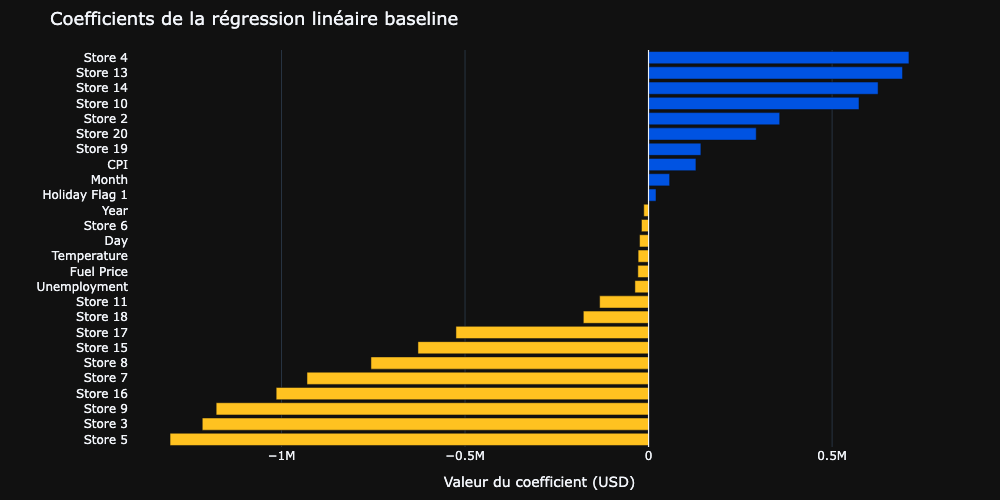

In [30]:
# Tri croissant pour un affichage de haut en bas par importance décroissante
coef_df_sorted = coef_df.sort_values("coefficient", ascending=True)

# Couleurs : bleu pour effet positif, jaune pour effet négatif (charte Walmart)
bar_colors = [
    DEFAULT_COLOR if c >= 0 else ALT_COLOR
    for c in coef_df_sorted["coefficient"]
]

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=coef_df_sorted["coefficient"],
        y=coef_df_sorted["feature"],
        orientation="h",
        marker_color=bar_colors,
    )
)

fig.add_vline(x=0, line=dict(color="white", width=1))

fig.update_layout(
    title="Coefficients de la régression linéaire baseline",
    xaxis_title="Valeur du coefficient (USD)",
    yaxis_title="",
    height=500,
    showlegend=False,
)
fig_name = "Coefficients de la regression lineaire baseline"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

In [31]:
# Modèle réduit aux seules dummies de magasin pour quantifier la part de variance expliquée par Store seul
store_only_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(drop="first", handle_unknown="error")),
        ("model", LinearRegression()),
    ]
)
store_only_pipeline.fit(X_train[["Store"]], y_train)

r2_store_train = store_only_pipeline.score(X_train[["Store"]], y_train)
r2_store_test = store_only_pipeline.score(X_test[["Store"]],  y_test)
r2_full_train = baseline_pipeline.score(X_train, y_train)
r2_full_test = baseline_pipeline.score(X_test, y_test)

print(f"R² modèle 'Store' uniquement   : train = {r2_store_train:.4f}, test = {r2_store_test:.4f}")
print(f"R² modèle baseline complet     : train = {r2_full_train:.4f}, test = {r2_full_test:.4f}")
print(f"Part de la variance test expliquée par Store seul : {r2_store_test / r2_full_test:.1%}")

R² modèle 'Store' uniquement   : train = 0.9571, test = 0.9356
R² modèle baseline complet     : train = 0.9732, test = 0.9524
Part de la variance test expliquée par Store seul : 98.2%


Trois enseignements ressortent :
- **Les 17 dummies de magasin concentrent l'essentiel du signal** : un modèle utilisant uniquement `Store` atteint un R² test de 0,9356, contre 0,9524 pour le modèle complet. Autrement dit, `Store` explique à lui seul 93,6% de la variance du CA hebdomadaire, soit 98% du pouvoir explicatif total du modèle. Les coefficients vont de -1,30M USD (Store 5) à +0,71M USD (Store 4) ; les valeurs négatives correspondent à des magasins structurellement plus petits que la référence (Store 1), les positives à des magasins plus grands.
- **Les variables économiques jouent un rôle de second ordre** : un écart-type supplémentaire de CPI est associé à +129k USD de ventes, contre -37k USD pour le chômage, -29k USD pour le prix du carburant et -28k USD pour la température. Ces ordres de grandeur sont 5 à 10 fois inférieurs aux effets magasin.
- **L'effet "jour férié" est anormalement faible** (+20k USD) et l'effet annuel quasi nul (-13k USD). Sur un jeu de seulement 126 lignes, cela peut traduire un manque de données plus qu'une absence réelle d'effet.

### 2.6 Bilan de la régression linéaire

Trois enseignements ressortent de cette régression baseline :

1. **Performance brute correcte** : R² de 0,9732 en entraînement et 0,9524 en test, MAE test d'environ 111k USD soit ~7% de la moyenne des ventes hebdomadaires. Le modèle capture donc l'essentiel du signal.

2. **Sur-apprentissage manifeste sur les erreurs absolues** : la RMSE est ~49% plus grande sur le test que sur le train (156k USD vs 105k USD), la MAE ~41% plus grande (111k USD vs 79k USD). Avec environ 100 observations d'entraînement pour 26 variables après "one-hot encoding", le ratio observations/variables (~4) est faible et laisse au modèle beaucoup de liberté pour s'ajuster au bruit.

3. **Hiérarchie des variables très contrastée** : les dummies des magasins concentrent l'information, avec des coefficients allant jusqu'à 1,3M USD en valeur absolue. Les indicateurs économiques (CPI, chômage, carburant, température) ont des effets compris entre -40k USD et +130k USD par écart-type, soit un ordre de grandeur inférieur. Les variables temporelles et le drapeau jour férié sont négligeables.

Pour mieux contrôler la complexité et améliorer la généralisation, la Partie 3 introduira une régularisation `Ridge` et/ou `Lasso`, dont les hyperparamètres seront optimisés par validation croisée. La régularisation devrait tirer parti du fait que les très gros coefficients magasin pourraient être atténués sans dégrader la performance prédictive.

---

## Partie 3 - Régularisation

### 3.1 Stratégie d'optimisation

La régularisation introduit un hyperparamètre `alpha` qui contrôle l'intensité de la pénalité appliquée aux coefficients. La valeur optimale dépend du jeu de données et doit être choisie par validation croisée sur l'ensemble d'entraînement, sans jamais utiliser l'ensemble de test (qui reste réservé à l'évaluation finale).

Choix méthodologiques :

- **Validation croisée** : `KFold` à 5 plis avec mélange aléatoire, fixé par `RANDOM_STATE` pour la reproductibilité. On ne peut pas stratifier `KFold` par `Store` en régression, mais le mélange aléatoire suffit ici.
- **Métrique de sélection** : R² (`scoring="r2"`), pour rester cohérent avec l'évaluation de la Partie 2 et faciliter la comparaison.
- **Grille d'`alpha`** : 13 valeurs réparties logarithmiquement entre `1e-2` et `1e4`, ce qui couvre une plage suffisante pour observer la transition entre faible et forte régularisation.

**Justification du nombre de plis** : avec environ 100 observations d'entraînement, `k=5` donne des plis de validation de ~20 observations et des plis d'entraînement de ~80 observations (80% du total). C'est le compromis classique entre biais (qui croît quand `k` diminue, car les plis d'entraînement s'éloignent du jeu complet) et variance (qui croît quand `k` augmente, car les plis de validation deviennent trop petits pour fournir une estimation stable du R²). À `k=10`, les plis de validation tomberaient à ~10 observations, ce qui est trop peu pour que le R² mesuré soit fiable. À `k=3`, les plis d'entraînement ne contiendraient que ~67 observations pour 26 variables après "one-hot encoding", ce qui dégraderait la qualité de l'ajustement.

In [32]:
# Grille d'alpha commune aux deux modèles
alpha_grid = np.logspace(-2, 4, 13)
print(f"Grille d'alpha testée ({len(alpha_grid)} valeurs) :")
print(np.round(alpha_grid, 4))

# Validation croisée à 5 plis avec mélange
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Grille d'alpha testée (13 valeurs) :
[1.0000000e-02 3.1600000e-02 1.0000000e-01 3.1620000e-01 1.0000000e+00
 3.1623000e+00 1.0000000e+01 3.1622800e+01 1.0000000e+02 3.1622780e+02
 1.0000000e+03 3.1622777e+03 1.0000000e+04]


### 3.2 Régression Ridge

La régression Ridge pénalise la somme des carrés des coefficients (norme L2). Elle réduit l'amplitude des coefficients sans jamais les annuler complètement, ce qui la rend adaptée lorsque toutes les variables ont a priori un rôle à jouer.

In [33]:
# Construction du pipeline Ridge avec recherche en grille
ridge_pipeline = build_pipeline(Ridge(random_state=RANDOM_STATE))
ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={"model__alpha": alpha_grid},
    scoring="r2",
    cv=cv,
    n_jobs=-1,
)
ridge_search.fit(X_train, y_train)

print(f"Meilleur alpha Ridge : {ridge_search.best_params_['model__alpha']:.4f}")
print(f"R² CV moyen          : {ridge_search.best_score_:.4f}")

Meilleur alpha Ridge : 0.1000
R² CV moyen          : 0.9414


### 3.3 Régression Lasso

La régression Lasso pénalise la somme des valeurs absolues des coefficients (norme L1). Contrairement à Ridge, elle peut annuler complètement certains coefficients et opère donc une sélection de variables, ce qui est précieux lorsque le nombre de variables est élevé par rapport au nombre d'observations.

In [34]:
# Construction du pipeline Lasso avec recherche en grille
# max_iter relevé pour garantir la convergence avec les petits alpha
lasso_pipeline = build_pipeline(Lasso(max_iter=50000, random_state=RANDOM_STATE))
lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid={"model__alpha": alpha_grid},
    scoring="r2",
    cv=cv,
    n_jobs=-1,
)
lasso_search.fit(X_train, y_train)

print(f"Meilleur alpha Lasso : {lasso_search.best_params_['model__alpha']:.4f}")
print(f"R² CV moyen          : {lasso_search.best_score_:.4f}")

Meilleur alpha Lasso : 1000.0000
R² CV moyen          : 0.9428


### 3.4 Effet de la régularisation sur le score

La courbe ci-dessous trace le R² moyen obtenu par validation croisée en fonction de `alpha`, pour Ridge et Lasso. Elle permet de visualiser le compromis biais-variance : à faible `alpha`, le modèle se rapproche de la régression linéaire non régularisée (risque de sur-apprentissage), à fort `alpha`, le modèle devient trop contraint (sous-apprentissage).

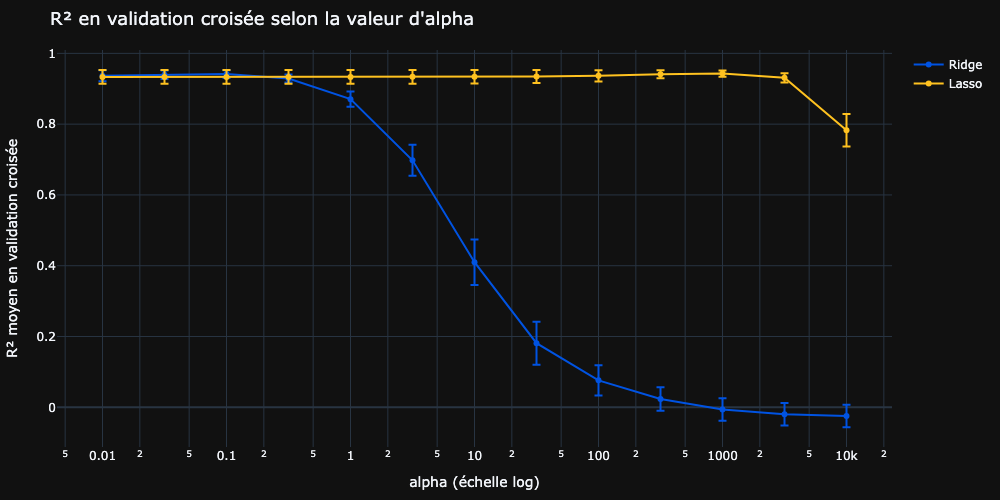

In [35]:
# Extraction des scores moyens et écarts-types par alpha
ridge_cv_scores = ridge_search.cv_results_["mean_test_score"]
ridge_cv_std = ridge_search.cv_results_["std_test_score"]
lasso_cv_scores = lasso_search.cv_results_["mean_test_score"]
lasso_cv_std = lasso_search.cv_results_["std_test_score"]

fig = go.Figure()

# Courbe Ridge avec bande d'incertitude (+/- 1 ecart-type)
fig.add_trace(
    go.Scatter(
        x=alpha_grid,
        y=ridge_cv_scores,
        mode="lines+markers",
        name="Ridge",
        line=dict(color=DEFAULT_COLOR, width=2),
        error_y=dict(type="data", array=ridge_cv_std, visible=True, color=DEFAULT_COLOR),
    )
)

# Courbe Lasso avec bande d'incertitude (+/- 1 ecart-type)
fig.add_trace(
    go.Scatter(
        x=alpha_grid, y=lasso_cv_scores,
        mode="lines+markers",
        name="Lasso",
        line=dict(color=ALT_COLOR, width=2),
        error_y=dict(type="data", array=lasso_cv_std, visible=True, color=ALT_COLOR),
    )
)

fig.update_layout(
    title="R² en validation croisée selon la valeur d'alpha",
    xaxis=dict(title="alpha (échelle log)", type="log"),
    yaxis_title="R² moyen en validation croisée",
    height=500,
)
fig_name = "r2 score vs alpha en validation croisee"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

### 3.5 Comparaison finale des trois modèles

Les trois modèles sont évalués sur le même découpage train/test que celui défini en 1.5.1, avec les trois métriques retenues en Partie 2 (R², RMSE, MAE).

In [36]:
# Récupération des deux meilleurs estimateurs régularisés
ridge_best = ridge_search.best_estimator_
lasso_best = lasso_search.best_estimator_

# Compilation des métriques pour les trois modèles
def evaluate(pipeline, label):
    """Compute train/test metrics for a fitted pipeline."""
    metrics = {
        "R² train":   r2_score(y_train, pipeline.predict(X_train)),
        "R² test":    r2_score(y_test,  pipeline.predict(X_test)),
        "RMSE train": root_mean_squared_error(y_train, pipeline.predict(X_train)),
        "RMSE test":  root_mean_squared_error(y_test,  pipeline.predict(X_test)),
        "MAE train":  mean_absolute_error(y_train, pipeline.predict(X_train)),
        "MAE test":   mean_absolute_error(y_test,  pipeline.predict(X_test)),
    }
    return pd.Series(metrics, name=label)


comparison = pd.concat([
    evaluate(baseline_pipeline, "Baseline"),
    evaluate(ridge_best,        f"Ridge (alpha={ridge_search.best_params_['model__alpha']:.2f})"),
    evaluate(lasso_best,        f"Lasso (alpha={lasso_search.best_params_['model__alpha']:.2f})"),
], axis=1)

# Mise en forme : 4 décimales pour le R², 2 pour les erreurs
comparison_display = comparison.copy()
for row in ["R² train", "R² test"]:
    comparison_display.loc[row] = comparison.loc[row].round(4)
for row in ["RMSE train", "RMSE test", "MAE train", "MAE test"]:
    comparison_display.loc[row] = comparison.loc[row].round(2)

print("Comparaison des trois modèles :\n")
print(comparison_display.to_string())

Comparaison des trois modèles :

               Baseline  Ridge (alpha=0.10)  Lasso (alpha=1000.00)
R² train         0.9732              0.9720                 0.9711
R² test          0.9524              0.9494                 0.9476
RMSE train  104645.8200         107011.6800            108574.4300
RMSE test   155737.4300         160484.8000            163293.0500
MAE train    78607.5000          80721.8900             82449.5400
MAE test    110653.6400         110892.6500            116684.1600


#### 3.5.1 Comparaison équitable en validation croisée

La comparaison de la cellule précédente mélange deux mesures de natures différentes : le R² CV moyen pour Ridge et Lasso, le R² test pour Baseline. Pour évaluer correctement l'apport de la régularisation, il faut comparer les trois modèles sur exactement le même protocole de validation croisée.

In [37]:
# Calcul du R² CV moyen pour chaque modèle, avec le même KFold
def cv_score_summary(pipeline, label):
    """Compute mean and std of R² across CV folds for a given pipeline."""
    scores = cross_val_score(pipeline, X_train, y_train, scoring="r2", cv=cv)
    return pd.Series({
        "R² CV moyen": scores.mean(),
        "R² CV écart-type": scores.std(),
        "R² CV min": scores.min(),
        "R² CV max": scores.max(),
    }, name=label)


cv_comparison = pd.concat([
    cv_score_summary(baseline_pipeline, "Baseline"),
    cv_score_summary(ridge_best,        "Ridge"),
    cv_score_summary(lasso_best,        "Lasso"),
], axis=1)

print("Performances en validation croisée (R² sur les 5 plis) :\n")
print(cv_comparison.round(4).to_string())

Performances en validation croisée (R² sur les 5 plis) :

                  Baseline   Ridge   Lasso
R² CV moyen         0.9335  0.9414  0.9428
R² CV écart-type    0.0195  0.0109  0.0086
R² CV min           0.9023  0.9247  0.9329
R² CV max           0.9598  0.9508  0.9546


#### 3.5.2 Diagnostic de Lasso à alpha=1000

Un `alpha` de 1000 pour Lasso est une régularisation très forte. Il faut vérifier combien de coefficients ont été annulés et s'assurer que le modèle n'a pas été "vidé" au point de ne prédire que la moyenne.

In [38]:
# Inspection des coefficients Lasso retenus
lasso_coefs = lasso_best.named_steps["model"].coef_
n_total = len(lasso_coefs)
n_zero = (lasso_coefs == 0).sum()
n_kept = n_total - n_zero

print(f"Coefficients Lasso : {n_kept} conservés / {n_total} ({n_zero} annulés)")
print(f"Amplitude max des coefficients conservés : {np.abs(lasso_coefs).max():,.2f} USD")

Coefficients Lasso : 25 conservés / 26 (1 annulés)
Amplitude max des coefficients conservés : 1,238,759.36 USD


#### 3.5.3 Diagnostic de Ridge à alpha=0,1

Un `alpha` de 0,1 pour Ridge est une régularisation très faible. Il faut vérifier que les coefficients restent dans un ordre de grandeur cohérent avec ceux de la baseline et identifier l'amplitude maximale, qui servira de référence pour situer les effets relatifs des variables.

In [39]:
def extract_coefs(pipeline, label):
    """Extract cleaned feature names and coefficients from a fitted pipeline."""
    features = pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefs = pipeline.named_steps["model"].coef_
    return pd.Series(
        coefs,
        index=[clean_feature_name(f) for f in features],
        name=label,
    )

In [40]:
# Inspection des coefficients Ridge retenus
ridge_coefs = ridge_best.named_steps["model"].coef_
n_total = len(ridge_coefs)
print(f"Coefficients Ridge : {n_total} conservés / {n_total} (aucun annulé, propriété de la norme L2)")
print(f"Amplitude max des coefficients : {np.abs(ridge_coefs).max():,.2f} USD")

# Effet relatif de l'IPC pour la recommandation marketing
ridge_cpi_coef = extract_coefs(ridge_best, "Ridge").loc["CPI"]
mean_sales = y.mean()
ridge_cpi_relative_mean = ridge_cpi_coef / mean_sales
ridge_cpi_relative_max  = ridge_cpi_coef / np.abs(ridge_coefs).max()

print(f"\nCoefficient CPI (Ridge)             : {ridge_cpi_coef:>12,.0f} USD par écart-type")
print(f"CA hebdomadaire moyen               : {mean_sales:>12,.0f} USD")
print(f"Effet IPC / CA moyen                : {ridge_cpi_relative_mean:>12.1%}")
print(f"Effet IPC / amplitude max des coefs : {ridge_cpi_relative_max:>12.1%}")

Coefficients Ridge : 26 conservés / 26 (aucun annulé, propriété de la norme L2)
Amplitude max des coefficients : 1,201,421.78 USD

Coefficient CPI (Ridge)             :      104,321 USD par écart-type
CA hebdomadaire moyen               :    1,257,990 USD
Effet IPC / CA moyen                :         8.3%
Effet IPC / amplitude max des coefs :         8.7%


### 3.6 Coefficients des modèles régularisés

La comparaison des coefficients entre les trois modèles éclaire la mécanique de la régularisation :

- **Ridge** réduit l'amplitude de tous les coefficients sans en annuler aucun,
- **Lasso** met à zéro les coefficients des variables qu'il juge superflues, opérant ainsi une sélection automatique.

Les variables retenues (ou conservées avec un poids significatif) par Lasso pourront être considérées comme les leviers les plus robustes pour expliquer les ventes hebdomadaires.

In [41]:
# Construction d'un tableau des coefficients pour les trois modèles
coefs_comparison = pd.concat([
    extract_coefs(baseline_pipeline, "Baseline"),
    extract_coefs(ridge_best, "Ridge"),
    extract_coefs(lasso_best, "Lasso"),
], axis=1)

# Tri par importance absolue dans le modèle baseline
coefs_comparison["abs_baseline"] = coefs_comparison["Baseline"].abs()
coefs_comparison = coefs_comparison.sort_values("abs_baseline", ascending=False)
coefs_comparison = coefs_comparison.drop(columns="abs_baseline")

print("Coefficients comparés (en USD) :\n")
print(coefs_comparison.round(0).to_string())

# Nombre de coefficients annulés par Lasso
n_zero_lasso = (coefs_comparison["Lasso"] == 0).sum()
print(f"\nVariables annulées par Lasso : {n_zero_lasso} / {len(coefs_comparison)}")

Coefficients comparés (en USD) :

                 Baseline      Ridge      Lasso
Store 5        -1303571.0 -1201422.0 -1238759.0
Store 3        -1215795.0 -1131959.0 -1164614.0
Store 9        -1177907.0 -1051075.0 -1082525.0
Store 16       -1014453.0  -919721.0  -975823.0
Store 7         -930559.0  -889559.0  -930958.0
Store 8         -756277.0  -661357.0  -677893.0
Store 4          709322.0   723868.0   599360.0
Store 13         691812.0   695630.0   572559.0
Store 15        -628266.0  -618037.0  -714856.0
Store 14         625247.0   639358.0   570271.0
Store 10         573219.0   547695.0   420479.0
Store 17        -524774.0  -484474.0  -580618.0
Store 2          357193.0   407931.0   361552.0
Store 20         293277.0   339491.0   283880.0
Store 18        -177754.0  -184684.0  -278844.0
Store 19         142502.0   130473.0        0.0
Store 11        -133308.0   -64039.0   -48983.0
CPI              129020.0   104321.0    67145.0
Month             57336.0    57839.0    56601.0
Unempl

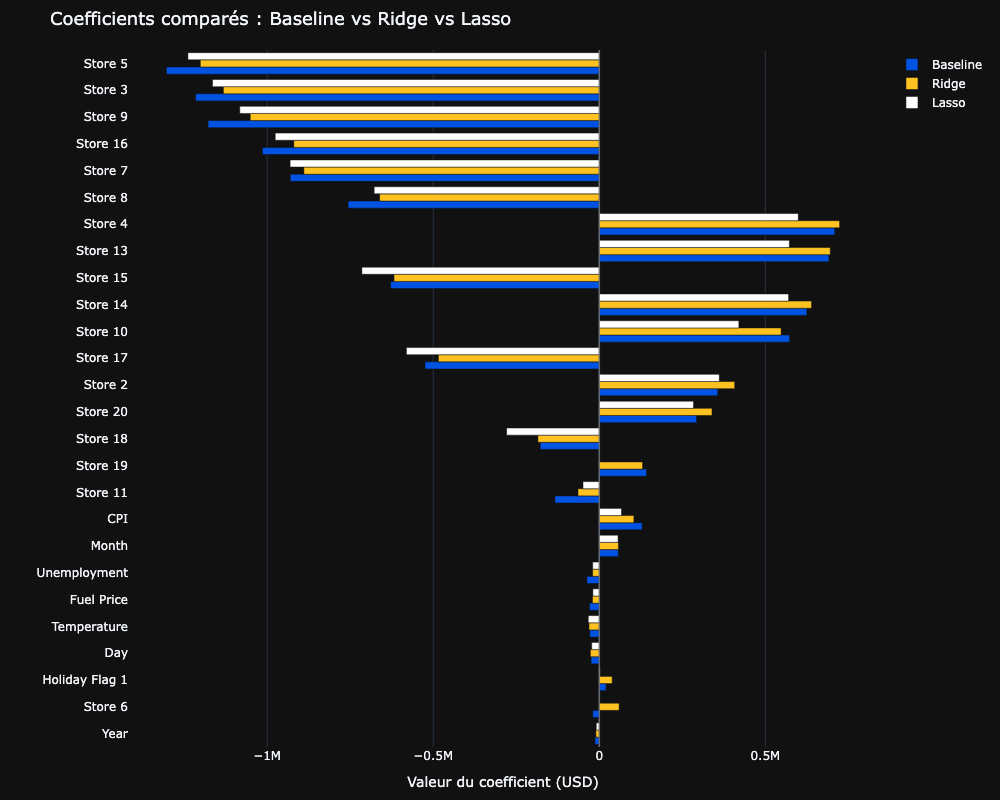

In [42]:
# Tri pour affichage de haut en bas par importance baseline décroissante
coefs_plot = coefs_comparison.iloc[::-1]

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=coefs_plot["Baseline"], y=coefs_plot.index,
        orientation="h", name="Baseline",
        marker_color=DEFAULT_COLOR,
    )
)

fig.add_trace(
    go.Bar(
        x=coefs_plot["Ridge"], y=coefs_plot.index,
        orientation="h", name="Ridge",
        marker_color=ALT_COLOR,
    )
)
fig.add_trace(
    go.Bar(
        x=coefs_plot["Lasso"], y=coefs_plot.index,
        orientation="h", name="Lasso",
        marker_color="white",
    )
)

fig.add_vline(x=0, line=dict(color="grey", width=1))

fig.update_layout(
    title="Coefficients comparés : Baseline vs Ridge vs Lasso",
    xaxis_title="Valeur du coefficient (USD)",
    yaxis_title="",
    height=800,
    barmode="group",
)
fig_name = "comparaison coefficients baseline vs ridge vs lasso"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

### 3.7 Bilan de la régularisation

**Modèle retenu : Ridge avec alpha = 0,1**, sur la base de la validation croisée à 5 plis qui constitue le protocole d'évaluation le plus fiable compte tenu de la petite taille du test set (26 observations).

Les deux modèles régularisés affichent des performances quasi identiques en validation croisée (R² CV moyen 0,9414 pour Ridge contre 0,9428 pour Lasso, écart de 0,0014 inférieur à l'écart-type entre plis). Le critère de performance ne tranche donc pas. Lasso n'annule qu'une seule variable sur 26 (`Store 19`), la sélection automatique espérée ne se concrétise donc pas réellement sur ce jeu de données. Dans ce contexte, Ridge est retenu, car la pénalité L2 est plus stable numériquement lorsque toutes les variables conservent un signal non nul.


**Apport de la régularisation, mesuré en validation croisée :**

| Métrique CV          | Baseline | Ridge  | Lasso  | Gain Ridge vs Baseline |
|----------------------|----------|--------|--------|------------------------|
| R² CV moyen          | 0,9335   | 0,9414 | 0,9428 | +0,0079                |
| R² CV écart-type     | 0,0195   | 0,0109 | 0,0086 | divisé par 1,8         |
| R² CV min (pire pli) | 0,9023   | 0,9247 | 0,9329 | +0,0224                |

Le gain moyen est modeste (~0,008 de R²) mais l'effet stabilisateur est franc : la variance des performances entre plis est presque divisée par deux. C'est précisément le rôle attendu d'une régularisation. Le pire cas (pli le plus défavorable) gagne 0,022 de R², ce qui réduit le risque opérationnel d'une prédiction très mauvaise sur certaines périodes.

**Note sur le R² test seul** : le tableau 3.5 montrait la baseline en tête (R² test 0,9524 contre 0,9476 pour Lasso). Cette inversion s'explique par la petite taille du test set (26 observations), qui rend le R² test sensible au tirage. La CV intègre 5 mesures et fournit une estimation plus robuste.

**Sélection de variables par Lasso (justification du choix de Ridge)** : Lasso n'annule qu'une seule variable sur 26 (`Store 19`), et n'écrase fortement que deux autres :

- `Store 6` : 763 USD (vs -19 308 USD en baseline)
- `Holiday_Flag 1` : 2 658 USD (vs 20 330 USD en baseline)

Ces trois variables coïncident avec celles identifiées comme négligeables en Partie 2, ce qui valide a posteriori l'analyse des coefficients de la baseline. En revanche, cela confirme que la sélection automatique espérée de Lasso n'apporte pas de valeur ajoutée significative sur ce jeu de données, et justifie le choix de Ridge comme modèle final.

## Conclusion

### Synthèse du projet

Ce projet visait à estimer le chiffre d'affaires hebdomadaire des magasins Walmart à partir d'indicateurs économiques et calendaires.

**Démarche :**

1. **Préparation des données** (Partie 1) : nettoyage du jeu initial de 150 lignes (retrait de 14 lignes sans cible et de 5 valeurs aberrantes), extraction de `Year`, `Month`, `Day` depuis `Date`, puis construction d'un pipeline scikit-learn avec imputation différenciée, standardisation et one-hot encoding. Jeu final : 131 observations.

2. **Modèle baseline** (Partie 2) : régression linéaire atteignant R² = 0,9524 sur le test et MAE = 111k USD (~7% de la moyenne). L'analyse des coefficients a montré que l'identité du magasin concentre l'essentiel du signal.

3. **Régularisation** (Partie 3) : Ridge et Lasso optimisés par `GridSearchCV` à 5 plis. Performances quasi identiques en validation croisée (écart de R² CV de 0,0014). Le modèle Ridge (alpha = 0,1) a été retenu pour sa stabilité numérique. Lasso n'apporte ni performance significativement meilleure (écart de R² CV de 0,0014) ni sélection de variables utile (1 seule annulée sur 26).

**Résultat principal :** Ridge apporte un gain modeste en R² moyen (+0,0079 vs baseline) mais réduit l'écart-type entre plis (0,0109 vs 0,0195), et fait passer le pire pli de R² = 0,9023 à 0,9247. L'effet stabilisateur attendu d'une régularisation est bien observé.

**Limites :**
- échantillon très réduit (131 observations pour 26 variables),
- couverture temporelle limitée à 2010-2012,
- hypothèse de linéarité qui ne capte ni interactions ni non-linéarités,
- **hétéroscédasticité des résidus** : le diagnostic en 2.4 a montré une dispersion croissante avec le niveau de CA prédit. L'annexe documente un test de transformation logarithmique de la cible : amélioration de la MAE (-6,8% sur le test) mais R² et RMSE quasi inchangés. La piste reste valable pour une v2 avec un échantillon plus large.

### Recommandations pour le service marketing

**1. Personnaliser les actions par magasin.** Les coefficients Ridge vont de -1,20M USD à +0,72M USD selon le magasin, un écart sans commune mesure avec les autres effets. Un budget marketing différencié par point de vente sera plus efficace qu'une campagne nationale uniforme.

**2. Suivre l'IPC comme principal signal macro-économique.** C'est le seul indicateur économique qui ressort nettement dans le modèle Ridge : un écart-type supplémentaire de CPI est associé à +104k USD de ventes hebdomadaires, soit ~8% du CA moyen. Les autres (chômage, carburant, température) ont des effets d'un ordre de grandeur inférieur.

**3. Ne pas miser sur les jours fériés sans données complémentaires.** `Holiday_Flag` reste un coefficient faible dans le modèle Ridge, cohérent avec l'analyse de la Partie 2. Avec 131 observations, le signal peut simplement être trop faible pour être détecté : une collecte ciblée autour des grandes périodes commerciales s'impose avant tout engagement budgétaire.

**4. Améliorer la précision du modèle.** La MAE test (~117k USD, ~8% de la moyenne) reste perfectible. Trois pistes : élargir le jeu de données à plusieurs milliers d'observations, tester une transformation logarithmique de la cible pour corriger l'hétéroscédasticité observée, et essayer des modèles non linéaires (forêts aléatoires, gradient boosting) qui captent les interactions sans hypothèse explicite.

**5. Communiquer les prévisions avec une fourchette.** Le pire pli en CV reste à R² = 0,9247, ce qui implique une dispersion non négligeable. Toute prédiction devrait être accompagnée d'une marge d'environ plus ou moins 120k USD (ordre de grandeur de la MAE test) pour éviter une lecture faussement précise.

---

## Annexe - Test d'une transformation logarithmique de la cible

### Motivation et protocole

- Diagnostic des résidus en 2.4 → hétéroscédasticité (dispersion qui croît avec la valeur prédite).
- Transformation `log(Weekly_Sales)` : remède classique pour stabiliser la variance.
- Hors périmètre Jedha (régression imposée sur la cible brute) → présenté en annexe.
- Protocole : même pipeline, même split, même `LinearRegression` que la baseline ; seule la cible change.
- Métriques recalculées en USD via `np.exp()` sur les prédictions, pour comparaison directe avec la baseline.

In [43]:
# Transformation de la cible
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# Réutilisation du pipeline baseline, cible transformée
baseline_log_pipeline = build_pipeline(LinearRegression())
baseline_log_pipeline.fit(X_train, y_train_log)

# Prédictions ramenées en USD pour comparaison directe
y_train_pred_log = np.exp(baseline_log_pipeline.predict(X_train))
y_test_pred_log = np.exp(baseline_log_pipeline.predict(X_test))

In [44]:
# Métriques en USD pour les deux modèles, sur les mêmes ensembles
log_comparison = pd.concat(
    [
        pd.Series(compute_metrics(y_train, y_train_pred), name="Baseline train"),
        pd.Series(compute_metrics(y_train, y_train_pred_log), name="Baseline log train"),
        pd.Series(compute_metrics(y_test, y_test_pred), name="Baseline test"),
        pd.Series(compute_metrics(y_test, y_test_pred_log), name="Baseline log test"),
    ],
    axis=1
)

log_comparison_display = log_comparison.copy()
log_comparison_display.loc["R²"] = log_comparison.loc["R²"].round(4)
log_comparison_display.loc["RMSE"] = log_comparison.loc["RMSE"].round(2)
log_comparison_display.loc["MAE"] = log_comparison.loc["MAE"].round(2)

print("Comparaison des métriques en USD (cible brute vs cible log) :\n")
print(log_comparison_display.to_string())

Comparaison des métriques en USD (cible brute vs cible log) :

      Baseline train  Baseline log train  Baseline test  Baseline log test
R²            0.9732              0.9763         0.9524             0.9498
RMSE     104645.8200          98505.4500    155737.4300        159839.9100
MAE       78607.5000          68680.6800    110653.6400        103178.3200


Moyenne des résidus (modèle log, retour USD) :
  Train :   3,093.39 USD
  Test  :  -1,968.77 USD


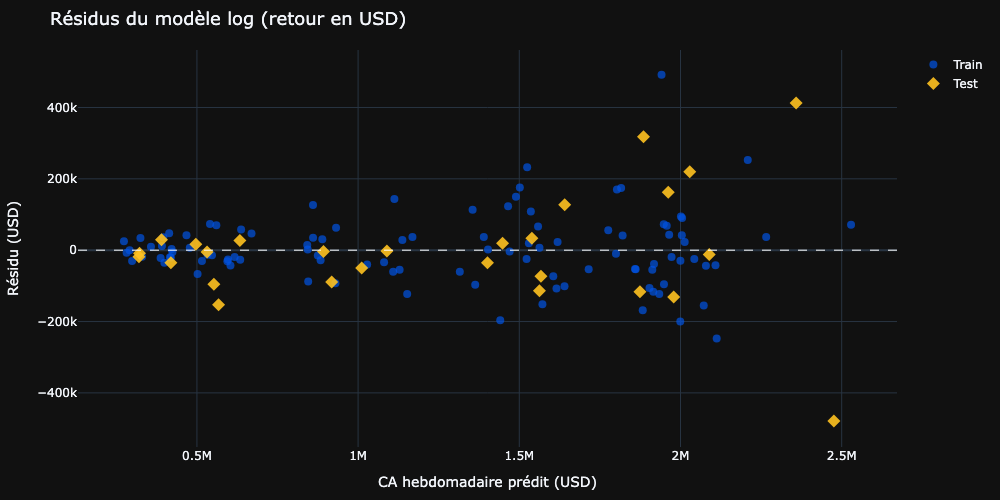

In [45]:
# Résidus en USD pour comparaison visuelle directe avec la section 2.4
residuals_train_log = y_train - y_train_pred_log
residuals_test_log = y_test - y_test_pred_log

print("Moyenne des résidus (modèle log, retour USD) :")
print(f"  Train : {residuals_train_log.mean():>10,.2f} USD")
print(f"  Test  : {residuals_test_log.mean():>10,.2f} USD")

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=y_train_pred_log, y=residuals_train_log,
        mode="markers", name="Train",
        marker=dict(color=DEFAULT_COLOR, size=8, opacity=0.7),
    )
)
fig.add_trace(
    go.Scatter(
        x=y_test_pred_log, y=residuals_test_log,
        mode="markers", name="Test",
        marker=dict(color=ALT_COLOR, size=10, opacity=0.9, symbol="diamond"),
    )
)
fig.add_hline(y=0, line=dict(color="white", dash="dash", width=1))
fig.update_layout(
    title="Résidus du modèle log (retour en USD)",
    xaxis_title="CA hebdomadaire prédit (USD)",
    yaxis_title="Résidu (USD)",
    height=500,
)
fig_name = "residus modele log"
index_image = export_figure_to_png(fig, idx_img=index_image, name=fig_name)
show_figure(fig)

### Verdict

**Comparaison des métriques (log vs baseline) :**

| Métrique    | Train brute | Train log | Test brute | Test log | Verdict test                |
|-------------|-------------|-----------|------------|----------|-----------------------------|
| R²          | 0,9732      | 0,9763    | 0,9524     | 0,9498   | quasi identique (-0,003)    |
| RMSE (USD)  | 104 646     | 98 505    | 155 737    | 159 840  | légèrement dégradée (+2,6%) |
| MAE (USD)   | 78 608      | 68 681    | 110 654    | 103 178  | améliorée (-6,8%)           |

**Lecture :**

- **Train** : log améliore les trois métriques (R², RMSE, MAE). Le modèle s'ajuste mieux aux données d'entraînement.
- **Test** : résultats mitigés.
  - MAE améliorée de 6,8% → log réduit l'erreur typique.
  - RMSE légèrement dégradée (+2,6%) → quelques grosses erreurs subsistent et pèsent plus dans la RMSE (qui pénalise les grandes erreurs de façon quadratique).
  - R² quasi inchangé.
- **Hétéroscédasticité** : forme en entonnoir toujours présente sur le graphique. Léger gain sur les faibles valeurs prédites (résidus mieux centrés), mais la dispersion croît toujours nettement avec le CA prédit. La transformation log ne corrige pas le problème sur ce jeu de données.
- **Moyenne des résidus** : train +3 093 USD, test -1 969 USD. Un léger biais est introduit par le retour `exp` (artefact connu : la moyenne de `exp(log(y) + bruit)` n'est pas `y`), mais reste négligeable face à la MAE.

**Conclusion :**

Bilan ambigu. Log améliore l'erreur typique (MAE) mais pas l'erreur quadratique (RMSE) ni le R². L'écart entre les deux modèles est plus faible que la variabilité attendue avec seulement 26 observations test.

→ **La transformation log n'est pas une amélioration franche sur ce jeu de données**, ni sur les métriques ni sur l'hétéroscédasticité. Elle reste une piste pour une v2 avec plus de données.